# Import libraries

In [2]:
!pip install -q py_vncorenlp seqeval torchinfo

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.1 MB/s eta 0:00:00


In [3]:
import os
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

import py_vncorenlp
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)

from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

# Download dataset

In [5]:
# "word" là bản đã được segment từ ví dụ "lịch sử" -> "lịch_sử"
dataset = load_dataset("phucdev/PhoNER_COVID19", "word")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

word/train-00000-of-00001.parquet:   0%|          | 0.00/366k [00:00<?, ?B/s]

word/validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

word/test-00000-of-00001.parquet:   0%|          | 0.00/247k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5027 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

# Load tokenizer & rdrsegmenter

In [6]:
save_dir = os.path.abspath('/content/VnCoreNLP')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    py_vncorenlp.download_model(save_dir=save_dir)

rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/content/VnCoreNLP')
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=True)

!cd /content/
# Cách dùng
# 1. Segment từ bằng rdrsegmenter
# ví dụ "Lịch sử" -> "Lịch_sử"
# segmented_list = rdrsegmenter.word_segment(text)
# segmented_text = " ".join(segmented_list)

# 2. Tokenize bằng PhoBERT Tokenizer
#inputs = tokenizer(
#    segmented_text,
#    padding='max_length',
#    truncation=True,
#    max_length=128,
#    return_tensors="pt"
#)

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Preprocessing

In [7]:
# Bộ dataset cần ép về chuẩn NFC để tokenizers mới không bị lỗi
def preprocess(word_list):
    cleaned_words = [unicodedata.normalize('NFC', w) for w in word_list]
    return cleaned_words

clean_dataset = dataset.map(
    lambda x: {'words': preprocess(x['words'])},
    num_proc=2
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

# Measure dataset length

In [8]:
def get_length(examples):
    return {
        "length": [len(ids) for ids in examples["words"]]
    }

length_dataset = clean_dataset.map(
    get_length,
    batched=True,
    num_proc=2,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

--- Statistics for train ---
Mean: 26.36 | Max: 161 | p95: 50 | p99: 65

--- Statistics for validation ---
Mean: 28.14 | Max: 138 | p95: 54 | p99: 72

--- Statistics for test ---
Mean: 28.56 | Max: 162 | p95: 55 | p99: 72



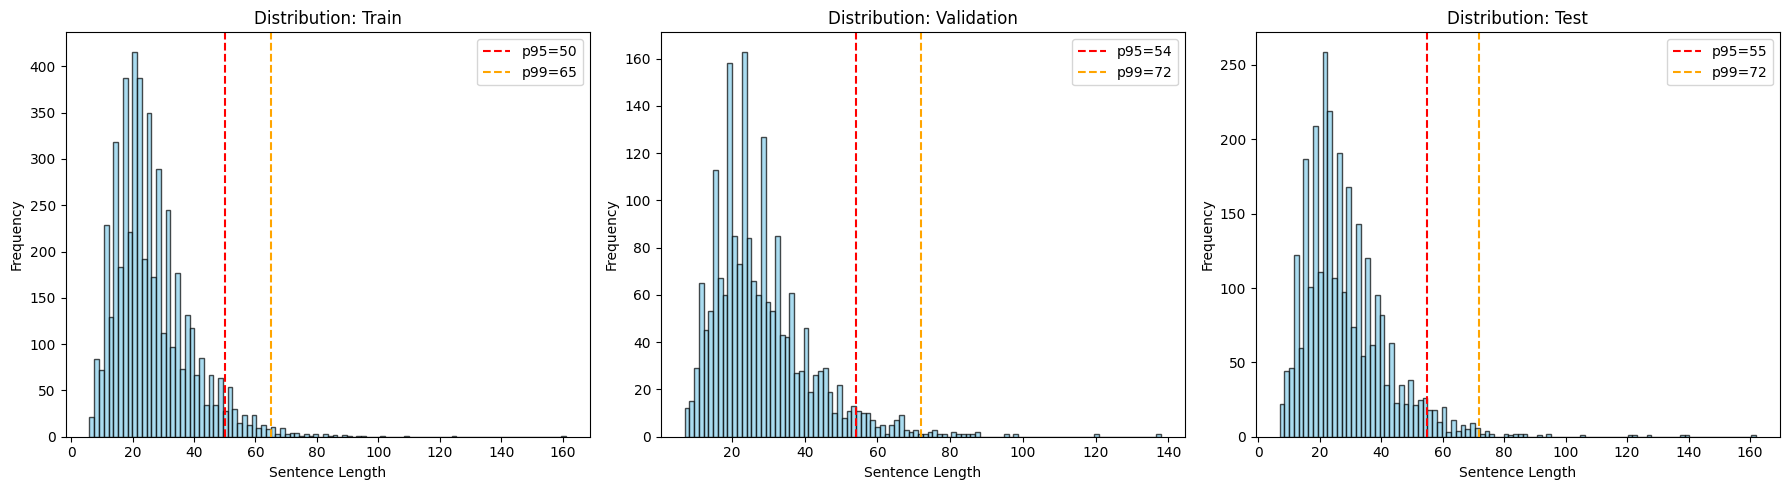

In [9]:
dataset_stats = {}
splits = ["train", "validation", "test"]

# Thiết lập figure cho plotting (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, split in enumerate(splits):
    # 1. Trích xuất độ dài
    lengths = np.array(length_dataset[split]["length"])

    # 2. Tính toán các chỉ số
    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    max_val = int(lengths.max())
    mean_val = lengths.mean()

    # 3. Lưu vào dictionary
    dataset_stats[split] = {
        "p95": p95,
        "p99": p99,
        "max_len": max_val,
        "mean": mean_val
    }

    # 4. In thông tin ra màn hình
    print(f"--- Statistics for {split} ---")
    print(f"Mean: {mean_val:.2f} | Max: {max_val} | p95: {p95} | p99: {p99}\n")

    # 5. Vẽ biểu đồ histogram lên subplot tương ứng
    axes[i].hist(lengths, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(p95, color='red', linestyle='--', label=f'p95={p95}')
    axes[i].axvline(p99, color='orange', linestyle='--', label=f'p99={p99}')

    axes[i].set_title(f'Distribution: {split.capitalize()}')
    axes[i].set_xlabel('Sentence Length')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Tokenize dataset

In [10]:
unique_tags = set()
for tags in clean_dataset['train']['tags']:
    unique_tags.update(tags)

unique_tags = sorted(list(unique_tags))

label2idx = {tag: i for i, tag in enumerate(unique_tags)}
idx2label = {i: tag for i, tag in enumerate(unique_tags)}

IGNORE_INDEX = -100

print(f"Số lượng nhãn: {len(unique_tags)}")
print("IGNORE_INDEX:", IGNORE_INDEX)
print("label2idx:", label2idx)

Số lượng nhãn: 20
IGNORE_INDEX: -100
label2idx: {'B-AGE': 0, 'B-DATE': 1, 'B-GENDER': 2, 'B-JOB': 3, 'B-LOCATION': 4, 'B-NAME': 5, 'B-ORGANIZATION': 6, 'B-PATIENT_ID': 7, 'B-SYMPTOM_AND_DISEASE': 8, 'B-TRANSPORTATION': 9, 'I-AGE': 10, 'I-DATE': 11, 'I-JOB': 12, 'I-LOCATION': 13, 'I-NAME': 14, 'I-ORGANIZATION': 15, 'I-PATIENT_ID': 16, 'I-SYMPTOM_AND_DISEASE': 17, 'I-TRANSPORTATION': 18, 'O': 19}


In [11]:
# Do PhoBERT sử dụng kĩ thuật bpe do đó ta phải chỉnh lại label cho chính xác
def tokenize_and_align_labels(examples):
    all_input_ids = []
    all_labels = []
    all_attention_masks = []

    cls_token_id = tokenizer.cls_token_id   # PhoBERT: <s>
    sep_token_id = tokenizer.sep_token_id   # PhoBERT: </s>


    for words, tags in zip(examples["words"], examples["tags"]):

        body_input_ids = []
        body_label_ids = []

        for word, tag in zip(words, tags):
            word_piece_ids = tokenizer.encode(word, add_special_tokens=False)
            if len(word_piece_ids) == 0:
                unk_id = tokenizer.unk_token_id
                word_piece_ids = [unk_id]

            body_input_ids.extend(word_piece_ids)

            body_label_ids.append(label2idx[tag])

            if len(word_piece_ids) > 1:
                body_label_ids.extend([IGNORE_INDEX] * (len(word_piece_ids) - 1))

        input_ids = [cls_token_id] + body_input_ids + [sep_token_id]
        labels = [IGNORE_INDEX] + body_label_ids + [IGNORE_INDEX]
        attention_mask = [1] * len(input_ids)

        all_input_ids.append(input_ids)
        all_labels.append(labels)
        all_attention_masks.append(attention_mask)

    return {
        "input_ids": all_input_ids,
        "labels": all_labels,
        "attention_mask": all_attention_masks,
    }

tokenized_dataset = clean_dataset.map(
    tokenize_and_align_labels,
    num_proc=2,
    batched=True,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

In [12]:
train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["validation"]
test_dataset = tokenized_dataset["test"]

# Utils

In [13]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=IGNORE_INDEX
)

In [14]:
# Sử dụng hàm này để tránh cho shape của train_loss, eval_loss lệch nhau dẫn tới
# vẽ biểu đồ không chính xác

def plot_loss_curves(history, title='Training and Validation Loss'):
    # Keep only full-epoch logs to align train/eval points cleanly.
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get('epoch')
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        if 'loss' in log and 'eval_loss' not in log:
            train_epoch_loss[epoch_int] = log['loss']
        if 'eval_loss' in log:
            eval_epoch_loss[epoch_int] = log['eval_loss']

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))
    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    if not epochs:
        raise ValueError('No aligned full-epoch train/eval loss points were found in trainer.state.log_history.')

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, eval_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:

def labels_from_predictions(predictions, labels):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [idx2label[p] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [idx2label[l] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    return true_labels, true_predictions

In [16]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    return {
        "f1": f1_score(true_labels, true_predictions),
    }

In [83]:
def evaluate_model(trainer, eval_dataset, split_name='test', model_name='rnn'):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    accuracy = accuracy_score(true_labels, true_predictions)
    precision = precision_score(true_labels, true_predictions)
    recall = recall_score(true_labels, true_predictions)
    f1 = f1_score(true_labels, true_predictions)

    print(f"Evaluation on {split_name} set using {model_name}")
    print("Classification Report:")
    print(classification_report(true_labels, true_predictions))

    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Model

## Model definition

### LSTM

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SwiGLU(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.w = nn.Linear(input_dim, output_dim)
        self.v = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return F.silu(self.w(x)) * self.v(x)

class LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, ignore_index,
                 num_layers=2, dropout=0.2, bidirectional=True, num_heads=4):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=ignore_index)

        # Sử dụng Dropout2d (hoạt động như Spatial Dropout cho văn bản)
        # Lưu ý: Yêu cầu input có dạng [batch_size, channels, length] nên cần transpose
        self.spatial_dropout = nn.Dropout1d(dropout)
        self.norm_emb = nn.LayerNorm(embedding_dim)

        # 1. Bi-LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        # 2. Multi-Head Self Attention
        # batch_first=True giúp nhận input trực tiếp từ LSTM [batch, seq_len, dim]
        self.attention = nn.MultiheadAttention(
            embed_dim=self.lstm_output_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # LayerNorm cho cơ chế Residual Connection
        self.norm_attn = nn.LayerNorm(self.lstm_output_dim)

        # 3. Classifier với SwiGLU
        # Mở rộng gấp đôi không gian đặc trưng sau Attention
        intermediate_dim = int(self.lstm_output_dim * 2.0)
        self.classifier = nn.Sequential(
            SwiGLU(self.lstm_output_dim, intermediate_dim),
            nn.Dropout(dropout),
            nn.Linear(intermediate_dim, output_dim)
        )

        self.ignore_index = ignore_index
        self.output_dim = output_dim

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # --- Lớp Embedding ---
        x = self.embedding(input_ids)

        # Áp dụng Spatial Dropout: (Batch, Seq_len, Dim) -> (Batch, Dim, Seq_len) -> (Batch, Seq_len, Dim)
        x = x.transpose(1, 2)
        x = self.spatial_dropout(x)
        x = x.transpose(1, 2)

        x = self.norm_emb(x)

        # --- Lớp LSTM ---
        if attention_mask is not None:
            lengths = attention_mask.sum(dim=1).cpu()
            packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            packed_out, _ = self.lstm(packed_x)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        else:
            lstm_out, _ = self.lstm(x)

        # --- Lớp Self-Attention kết hợp Residual Connection ---
        # Query, Key, Value đều là đầu ra của LSTM
        attn_out, _ = self.attention(query=lstm_out, key=lstm_out, value=lstm_out)

        # Residual Connection: Cộng đầu ra của LSTM với đầu ra của Attention, sau đó chuẩn hóa
        context = self.norm_attn(lstm_out + attn_out)

        # --- Lớp Classifier ---
        logits = self.classifier(context)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.output_dim),
                labels.view(-1),
                ignore_index=self.ignore_index,
                label_smoothing=0.1
            )

        return {"loss": loss, "logits": logits}

## LSTM Model

In [75]:
lstm_model = LSTM(
    vocab_size=64000,
    embedding_dim=256,
    hidden_dim=256,
    output_dim=len(unique_tags),
    ignore_index=IGNORE_INDEX,
    dropout=0.1,
    bidirectional=True,
    num_layers=2
)

In [76]:

summary(lstm_model, input_size=(1, 10), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
LSTMAttention_SwiGLU                     [1, 10, 20]               --
├─Embedding: 1-1                         [1, 10, 256]              16,384,000
├─Dropout1d: 1-2                         [1, 256, 10]              --
├─LayerNorm: 1-3                         [1, 10, 256]              512
├─LSTM: 1-4                              [1, 10, 512]              2,629,632
├─MultiheadAttention: 1-5                [1, 10, 512]              1,050,624
├─LayerNorm: 1-6                         [1, 10, 512]              1,024
├─Sequential: 1-7                        [1, 10, 20]               --
│    └─SwiGLU: 2-1                       [1, 10, 1024]             --
│    │    └─Linear: 3-1                  [1, 10, 1024]             525,312
│    │    └─Linear: 3-2                  [1, 10, 1024]             525,312
│    └─Dropout: 2-2                      [1, 10, 1024]             --
│    └─Linear: 2-3                       [1, 10, 

### Training

In [77]:
training_args = TrainingArguments(
    output_dir='/content/lstm_ner',
    num_train_epochs=100,
    learning_rate=5e-4,
    weight_decay=0.01,
    max_grad_norm=1.0,
    warmup_steps = 50,
    per_device_train_batch_size=512,
    per_device_eval_batch_size=512,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True
)

trainer = Trainer(
    model=lstm_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)],
)

Phần warning khi train không quan trọng tại vì đã cài đặt bỏ qua chúng trong phần model rồi.

In [78]:
train_result = trainer.train()
print('Train result:', train_result)

Epoch,Training Loss,Validation Loss,F1
1,2.810582,2.336193,0.000000
2,1.734957,1.698256,0.000000
3,1.369462,1.310109,0.005647
4,1.138323,1.126696,0.182539
5,0.959015,0.947976,0.525442
6,0.839398,0.854642,0.655168
7,0.771914,0.802990,0.737367
8,0.732167,0.770943,0.779894
9,0.705238,0.754336,0.800546
10,0.687092,0.736645,0.822981


Train result: TrainOutput(global_step=430, training_loss=0.7488163709640503, metrics={'train_runtime': 341.6964, 'train_samples_per_second': 1471.189, 'train_steps_per_second': 2.927, 'total_flos': 0.0, 'train_loss': 0.7488163709640503, 'epoch': 43.0})


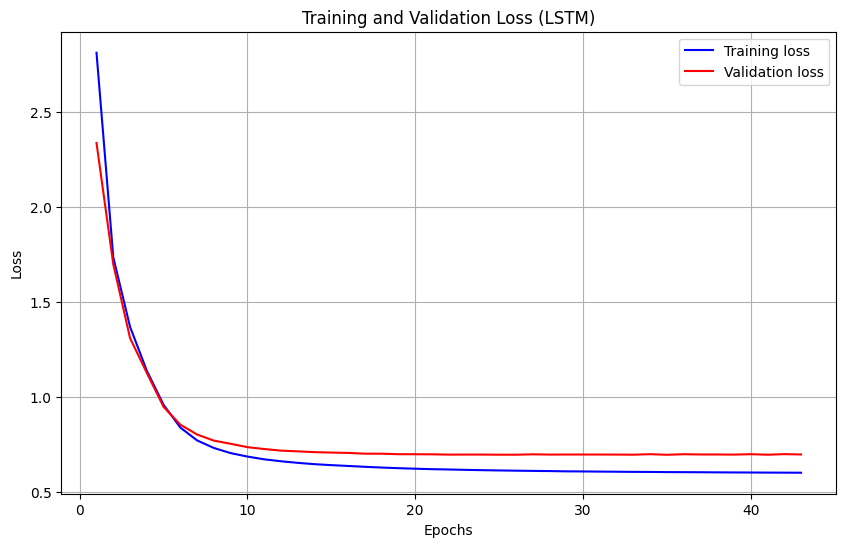

In [80]:
history = trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (LSTM)')

### Evaluate

Nhớ lưu cả biến result sau khi đánh giá để lúc sau còn vẽ biểu đồ,...

In [84]:
lstm_result = evaluate_model(trainer, test_dataset, split_name='test', model_name='LSTM')

Evaluation on test set using LSTM
Classification Report:
                     precision    recall  f1-score   support

                AGE       0.92      0.97      0.94       582
               DATE       0.96      0.96      0.96      1654
             GENDER       0.93      0.95      0.94       462
                JOB       0.57      0.47      0.52       173
           LOCATION       0.87      0.87      0.87      4441
               NAME       0.91      0.74      0.81       318
       ORGANIZATION       0.77      0.75      0.76       771
         PATIENT_ID       0.95      0.97      0.96      2005
SYMPTOM_AND_DISEASE       0.81      0.75      0.78      1136
     TRANSPORTATION       0.85      0.82      0.83       193

          micro avg       0.89      0.88      0.88     11735
          macro avg       0.85      0.82      0.84     11735
       weighted avg       0.88      0.88      0.88     11735

Accuracy: 0.9612736058264666
Precision: 0.8858616244091104
Recall: 0.8783127396676609


### Save model weight

In [82]:
# save model
trainer.save_model('/content/lstm_ner_final')